In [ ]:
import pandas as pd

df = pd.read_csv("customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Spending_Level
0,5735,1991,Master,Single,90638.0,0,0,2/13/2014,29,1156,...,0,1,0,0,0,3,11,0,2525,High
1,5350,1991,Master,Single,90638.0,0,0,2/13/2014,29,1156,...,0,1,0,0,0,3,11,1,2525,High
2,1763,1988,Graduation,Together,87679.0,0,0,7/27/2013,62,1259,...,0,1,1,0,0,3,11,1,2524,High
3,4580,1969,Graduation,Married,75759.0,0,0,10/25/2013,46,1394,...,0,1,1,0,0,3,11,1,2486,High
4,4475,1949,PhD,Married,69098.0,0,0,2/16/2013,82,1315,...,0,0,0,0,0,3,11,0,2440,High


In [ ]:
df.shape

(2240, 31)

In [ ]:
df['Age'] = 2026 - df['Year_Birth']
df[['Year_Birth','Age']].head()

,Year_Birth,Age
0,1991,35
1,1991,35
2,1988,38
3,1969,57
4,1949,77


In [ ]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df[['Total_Spending']].head()

,Total_Spending
0,2525
1,2525
2,2524
3,2486
4,2440


In [ ]:
features = df[['Age', 'Income', 'Total_Spending']]
features.head()

,Age,Income,Total_Spending
0,35,90638.0,2525
1,35,90638.0,2525
2,38,87679.0,2524
3,57,75759.0,2486
4,77,69098.0,2440


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

scaled_data[:5]

array([[-1.85238848,  1.53401496,  3.18743477],
       [-1.85238848,  1.53401496,  3.18743477],
       [-1.60200025,  1.415808  ,  3.18577396],
       [-0.01620817,  0.93962449,  3.12266308],
       [ 1.65304666,  0.67352899,  3.04626569]])

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

df['Cluster'].value_counts()

,count
Cluster,
1,936
2,657
0,647


In [ ]:
df.groupby('Cluster')[['Age', 'Income', 'Total_Spending']].mean()

,Age,Income,Total_Spending
Cluster,,,
0,70.140649,53428.785162,498.910355
1,49.830128,34968.632479,152.641026
2,54.936073,75668.190259,1356.652968


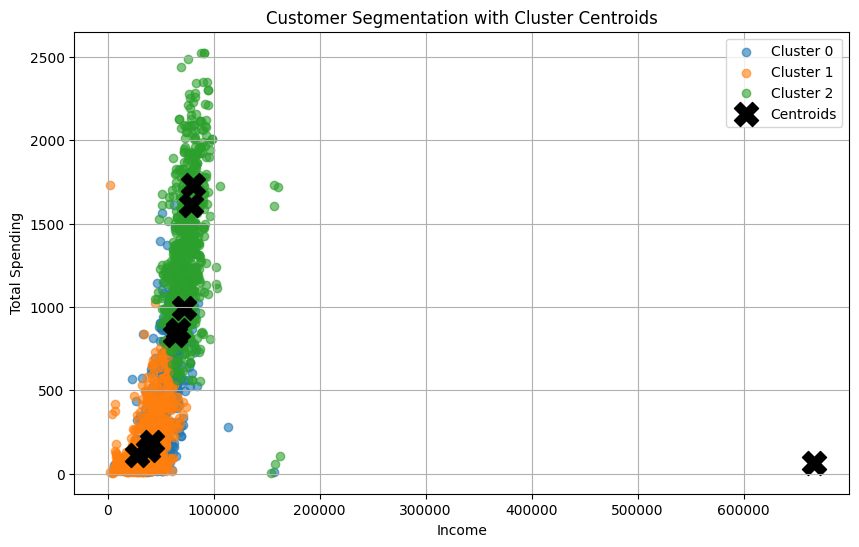

In [ ]:
import numpy as np

centroids = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

plt.figure(figsize=(10,6))

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    plt.scatter(
        subset['Income'],
        subset['Total_Spending'],
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

plt.scatter(
    centroids_original[:,1],
    centroids_original[:,2],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation with Cluster Centroids")
plt.legend()
plt.grid(True)
plt.show()

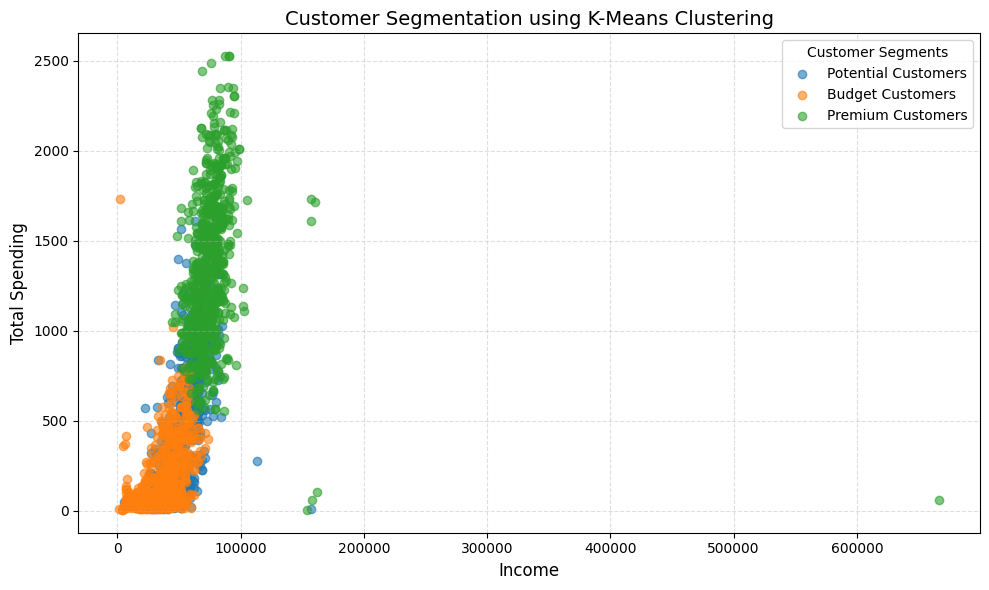

In [ ]:
import matplotlib.pyplot as plt

# Create a copy (optional but clean practice)
df_plot = df.copy()

# Rename clusters professionally based on your interpretation
cluster_names = {
    2: "Premium Customers",
    0: "Potential Customers",
    1: "Budget Customers"
}

plt.figure(figsize=(10,6))

for cluster in sorted(df_plot['Cluster'].unique()):
    subset = df_plot[df_plot['Cluster'] == cluster]

    plt.scatter(
        subset['Income'],
        subset['Total_Spending'],
        alpha=0.6,
        label=cluster_names[cluster]
    )

plt.xlabel("Income", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)
plt.title("Customer Segmentation using K-Means Clustering", fontsize=14)

plt.legend(title="Customer Segments")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

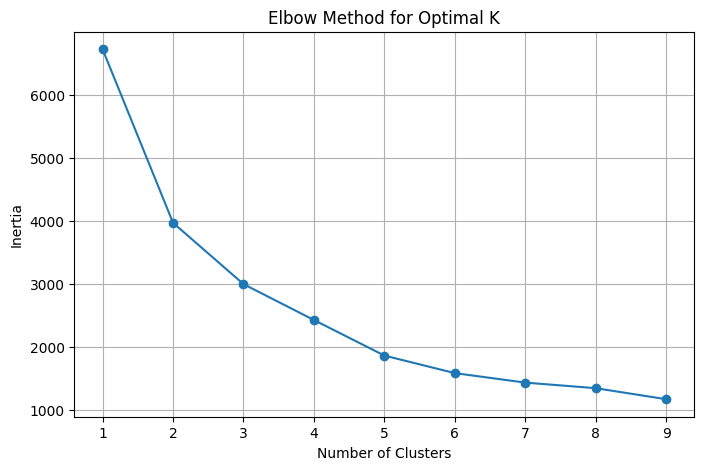

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

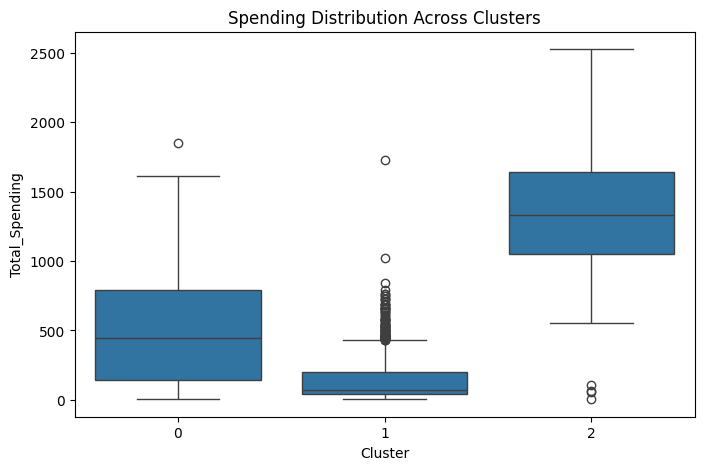

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Total_Spending', data=df)
plt.title("Spending Distribution Across Clusters")
plt.show()